In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os




In [2]:
df_rating = pd.read_csv("../data/raw/music/user_artists.dat",sep='\t', encoding='latin-1')
df_music = pd.read_csv("../data/raw/music/artists.dat", sep='\t', encoding='latin-1')
# df_user = pd.read_csv("../data/raw/movie/u.user",sep='|', encoding='latin-1', header=None, names=user_columns

# Rating 

In [3]:
df_rating.head()

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [4]:
df_music.head()

,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [5]:
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   userID    92834 non-null  int64
 1   artistID  92834 non-null  int64
 2   weight    92834 non-null  int64
dtypes: int64(3)
memory usage: 2.1 MB


In [6]:
duplicates_rating = df_rating.duplicated().sum()
print(f"Duplicate rows: {duplicates_rating}")


Duplicate rows: 0


In [7]:
df_rating.describe()

,userID,artistID,weight
count,92834.000000,92834.000000,92834.00000
mean,1037.010481,3331.123145,745.24393
std,610.870436,4383.590502,3751.32208
min,2.000000,1.000000,1.00000
25%,502.000000,436.000000,107.00000
50%,1029.000000,1246.000000,260.00000
75%,1568.000000,4350.000000,614.00000
max,2100.000000,18745.000000,352698.00000


In [8]:
# Step 1: Define function for scaling and rounding
def scale_weights(group):
    min_w, max_w = group['weight'].min(), group['weight'].max()
    if min_w == max_w:
        group['weight'] = 3  # neutral value
    else:
        group['weight'] = 1 + (group['weight'] - min_w) / (max_w - min_w) * 4
    
    # Round to 2 decimal places
    group['weight'] = group['weight'].round(2)
    return group

# Step 2: Apply per user
df_rating = df_rating.groupby('userID').apply(scale_weights).reset_index(drop=True)


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_88756\1419129643.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rating = df_rating.groupby('userID').apply(scale_weights).reset_index(drop=True)


In [9]:
df_rating.describe()

,userID,artistID,weight
count,92834.000000,92834.000000,92834.000000
mean,1037.010481,3331.123145,1.491974
std,610.870436,4383.590502,0.804723
min,2.000000,1.000000,1.000000
25%,502.000000,436.000000,1.040000
50%,1029.000000,1246.000000,1.170000
75%,1568.000000,4350.000000,1.550000
max,2100.000000,18745.000000,5.000000


<Axes: xlabel='weight', ylabel='Count'>

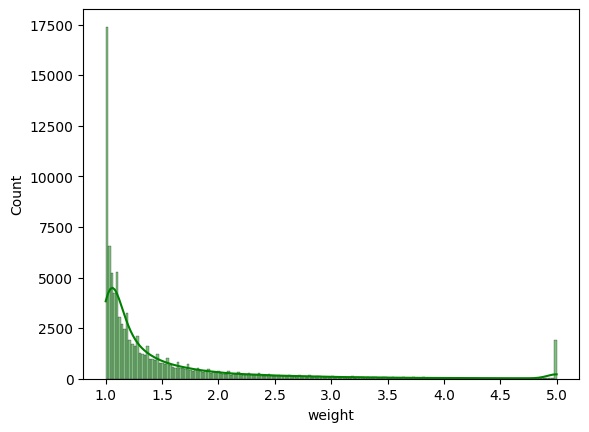

In [10]:
sns.histplot(df_rating['weight'], kde=True, edgecolor='black', color='green')


- From this we can see that the most user rated the music in the range of 1-2.
- After 2 there is the sudden steap in the graphs.
- Near 5 we are seeing the one vertical line which shows that count of the user increase. 

# Music


In [11]:
df_music.head()

,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [12]:
df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17632 entries, 0 to 17631
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          17632 non-null  int64 
 1   name        17632 non-null  object
 2   url         17632 non-null  object
 3   pictureURL  17188 non-null  object
dtypes: int64(1), object(3)
memory usage: 551.1+ KB


In [13]:
print(df_music.isnull().sum())


id              0
name            0
url             0
pictureURL    444
dtype: int64


In [14]:
df_music[df_music['pictureURL'].isnull()]


,id,name,url,pictureURL
105,111,Pleq & Anna Rose Carter,http://www.last.fm/music/+noredirect/Pleq%2B%2...,NaN
113,119,billy gomberg + offthesky,http://www.last.fm/music/+noredirect/billy%2Bg...,NaN
118,124,Shinkei & Mise En Scene,http://www.last.fm/music/Shinkei%2B%2526%2BMis...,NaN
127,133,Lauki,http://www.last.fm/music/Lauki,NaN
392,398,www.DjFahad.com,http://www.last.fm/music/www.DjFahad.com,NaN
...,...,...,...,...
17504,18601,uwe hÃ¼bner-der deutsche hitmix,http://www.last.fm/music/uwe+h%C3%BCbner-der+d...,NaN
17525,18622,Pete Hopkins,http://www.last.fm/music/Pete+Hopkins,NaN
17542,18646,shaggy and big yard crew,http://www.last.fm/music/shaggy+and+big+yard+crew,NaN
17544,18648,Ramin Djawadi And The RZA,http://www.last.fm/music/Ramin+Djawadi+And+The...,NaN


In [15]:
df_music.fillna(0, inplace=True)


In [16]:
df_music[df_music['pictureURL']==0]


,id,name,url,pictureURL
105,111,Pleq & Anna Rose Carter,http://www.last.fm/music/+noredirect/Pleq%2B%2...,0
113,119,billy gomberg + offthesky,http://www.last.fm/music/+noredirect/billy%2Bg...,0
118,124,Shinkei & Mise En Scene,http://www.last.fm/music/Shinkei%2B%2526%2BMis...,0
127,133,Lauki,http://www.last.fm/music/Lauki,0
392,398,www.DjFahad.com,http://www.last.fm/music/www.DjFahad.com,0
...,...,...,...,...
17504,18601,uwe hÃ¼bner-der deutsche hitmix,http://www.last.fm/music/uwe+h%C3%BCbner-der+d...,0
17525,18622,Pete Hopkins,http://www.last.fm/music/Pete+Hopkins,0
17542,18646,shaggy and big yard crew,http://www.last.fm/music/shaggy+and+big+yard+crew,0
17544,18648,Ramin Djawadi And The RZA,http://www.last.fm/music/Ramin+Djawadi+And+The...,0


#  Multivariate Analysis

In [17]:
df_ratings_music = df_rating.merge(df_music, left_on='artistID', right_on='id', how='inner')


In [18]:
df_ratings_music.head()

,userID,artistID,weight,id,name,url,pictureURL
0,2,51,5.00,51,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,4.30,52,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,4.19,53,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,3.86,54,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,3.44,55,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...


In [19]:
df_ratings_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   userID      92834 non-null  int64  
 1   artistID    92834 non-null  int64  
 2   weight      92834 non-null  float64
 3   id          92834 non-null  int64  
 4   name        92834 non-null  object 
 5   url         92834 non-null  object 
 6   pictureURL  92834 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.0+ MB


In [20]:
duplicates = df_ratings_music.duplicated()
print("Total duplicate rows:", duplicates.sum())


Total duplicate rows: 0


## Top Artists by Interaction

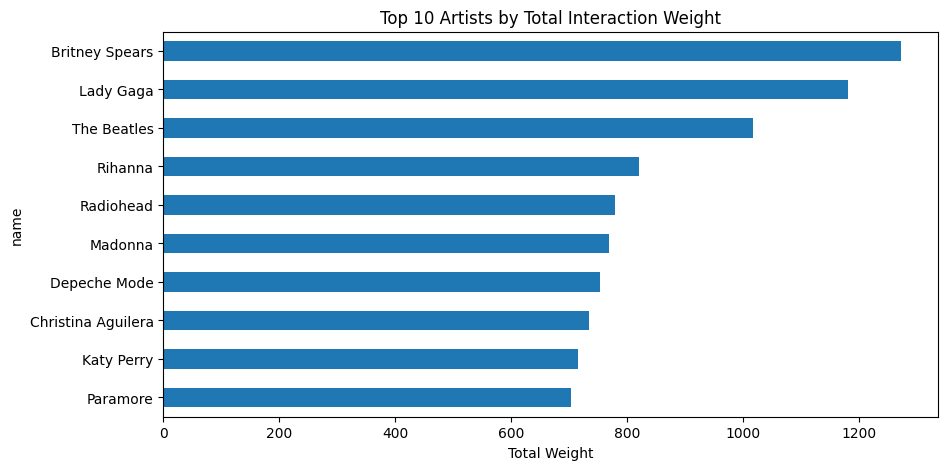

In [21]:
top_artists = df_ratings_music.groupby('name')['weight'].sum().sort_values(ascending=False).head(10)
top_artists.plot(kind='barh', title='Top 10 Artists by Total Interaction Weight', figsize=(10, 5))
plt.xlabel('Total Weight')
plt.gca().invert_yaxis()
plt.show()


## Who Contributes Most?

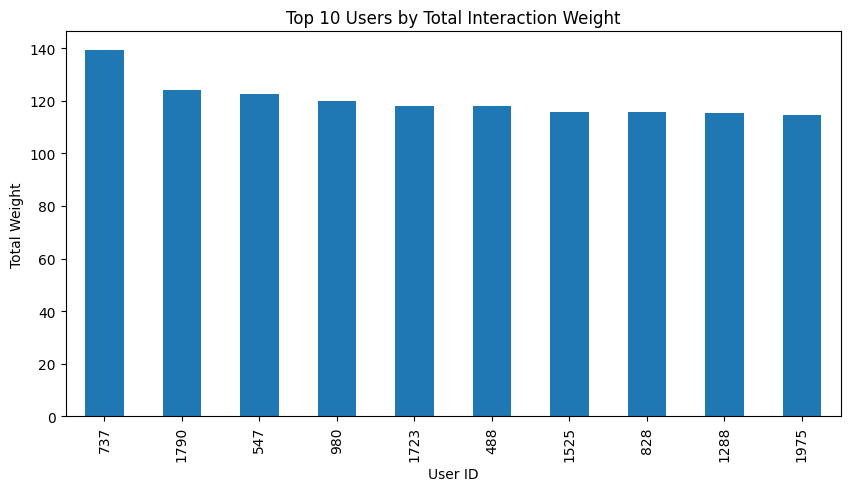

In [22]:
top_users = df_ratings_music.groupby('userID')['weight'].sum().sort_values(ascending=False).head(10)
top_users.plot(kind='bar', title='Top 10 Users by Total Interaction Weight', figsize=(10, 5))
plt.ylabel('Total Weight')
plt.xlabel('User ID')
plt.show()


- From this we can see that which user is listning music most.
- Means he/she is the regular or frequent listner.
- If we implement some subscription than there is the chances that he would buy.

## Heatmap of Top Users × Top Artists

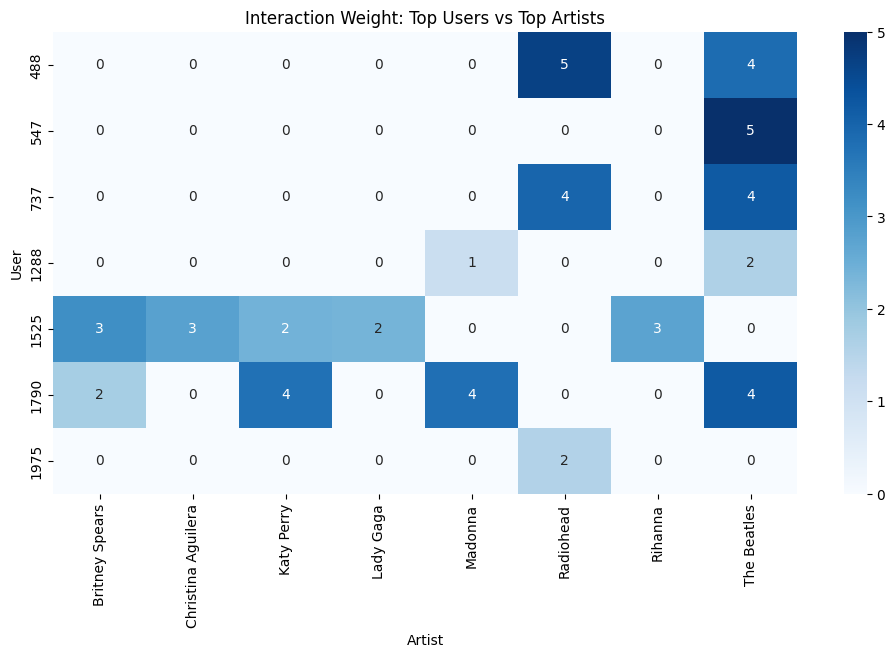

In [23]:
top_users = df_ratings_music.groupby('userID')['weight'].sum().nlargest(10).index
top_artists = df_ratings_music.groupby('artistID')['weight'].sum().nlargest(10).index

heatmap_data = df_ratings_music[df_ratings_music['userID'].isin(top_users) & df_ratings_music['artistID'].isin(top_artists)]
pivot = heatmap_data.pivot_table(index='userID', columns='name', values='weight', aggfunc='sum', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Interaction Weight: Top Users vs Top Artists')
plt.xlabel('Artist')
plt.ylabel('User')
plt.show()


In [25]:
base_path = r"E:\GitHub Repo's\Multi_domain_Recommendation\data\processed"

# Define datasets per domain
datasets = {
    "music": {
        "music_info": df_music,
        "music_rating": df_rating
    }
}

# Save each table in its domain folder
for domain, tables in datasets.items():
    domain_path = os.path.join(base_path, domain)
    os.makedirs(domain_path, exist_ok=True)
    
    for table_name, df in tables.items():
        file_path = os.path.join(domain_path, f"{table_name}.csv")
        df.to_csv(file_path, index=False)
        print(f"✅ Saved: {file_path}")


✅ Saved: E:\GitHub Repo's\Multi_domain_Recommendation\data\processed\music\music_info.csv
✅ Saved: E:\GitHub Repo's\Multi_domain_Recommendation\data\processed\music\music_rating.csv


In [26]:
df_rating.head()

,userID,artistID,weight
0,2,51,5.00
1,2,52,4.30
2,2,53,4.19
3,2,54,3.86
4,2,55,3.44
